# 1. Project Topic, Goals and Requirements Analysis


The goal of this project is to build a machine learning model that predicts the selling price of a used car based on its technical specifications and seller information. The problem we aim to solve is the difficulty of fairly pricing vehicles on the secondary market. Using artificial intelligence enables more accurate, automated, and scalable data analysis, allowing for quick and reliable price recommendations.

# 2. Dataset and Data Preparation


Data comes from an open-source dataset containing information about used cars. Each record represents one vehicle and includes the following columns:

**name**: car name (e.g. "Hyundai Verna 1.6 SX")

**year**: year of manufacture

**selling_price**: sale price (target variable)

**km_driven**: mileage in kilometres

**fuel**: fuel type (e.g. Diesel, Petrol, CNG)

**seller_type**: type of seller (e.g. individual, dealer)

**transmission**: gearbox type (manual, automatic)

**owner**: number of previous owners (e.g. first owner, second owner, etc.)

These features cover all key factors that affect a vehicle's value, making them ideal for building a predictive model.

**Dataset used:**

In [1]:
import pandas as pd
df = pd.read_excel('/content/sample_data/used_car_price_prediction_database.xlsx')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,6000.0,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,13500.0,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,60000.0,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,25000.0,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,45000.0,141000,Diesel,Individual,Manual,Second Owner


**Data cleaning process:**

**1. Replace name column with brand**

The vehicle brand is extracted from the name, as the full model name adds little predictive value to our project.

In [2]:
# Extract vehicle brand (first word from 'name')
df['brand'] = df['name'].apply(lambda x: x.split()[0])
df.drop('name', axis=1, inplace=True)
df.head()


,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,6000.0,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,13500.0,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,60000.0,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,25000.0,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,45000.0,141000,Diesel,Individual,Manual,Second Owner,Honda


**2. Transform year → vehicle age**

In [3]:
df['car_age'] = 2026 - df['year']
df.drop('year', axis=1, inplace=True)
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,6000.0,70000,Petrol,Individual,Manual,First Owner,Maruti,19
1,13500.0,50000,Petrol,Individual,Manual,First Owner,Maruti,19
2,60000.0,100000,Diesel,Individual,Manual,First Owner,Hyundai,14
3,25000.0,46000,Petrol,Individual,Manual,First Owner,Datsun,9
4,45000.0,141000,Diesel,Individual,Manual,Second Owner,Honda,12


**3. Encode owner as numeric values**

In [4]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 0
}
df['owner'] = df['owner'].map(owner_map)
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,6000.0,70000,Petrol,Individual,Manual,1,Maruti,19
1,13500.0,50000,Petrol,Individual,Manual,1,Maruti,19
2,60000.0,100000,Diesel,Individual,Manual,1,Hyundai,14
3,25000.0,46000,Petrol,Individual,Manual,1,Datsun,9
4,45000.0,141000,Diesel,Individual,Manual,2,Honda,12


**4. One-hot encoding for categorical variables**

In [5]:
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'brand'])
df.head()

,selling_price,km_driven,owner,car_age,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,6000.0,70000,1,19,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,13500.0,50000,1,19,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,60000.0,100000,1,14,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,25000.0,46000,1,9,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,45000.0,141000,2,12,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**5. Normalize km_driven**

In [6]:
import joblib
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['km_driven'] = scaler.fit_transform(df[['km_driven']])
joblib.dump(scaler, "scaler_km.pkl")
df.head()

,selling_price,km_driven,owner,car_age,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,6000.0,0.081139,1,19,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,13500.0,-0.347689,1,19,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,60000.0,0.724381,1,14,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,25000.0,-0.433455,1,9,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,45000.0,1.603479,2,12,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**6. Convert True/False values to 0/1**

In [7]:
df = df.replace({True: 1, False: 0})

df.head()

/tmp/ipykernel_5459/2661847449.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


,selling_price,km_driven,owner,car_age,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Dealer,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,6000.0,0.081139,1,19,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,13500.0,-0.347689,1,19,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,60000.0,0.724381,1,14,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,25000.0,-0.433455,1,9,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,45000.0,1.603479,2,12,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 3. AI Model Selection and Implementation

Data split:

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Split features and target variable
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

# 2. Save full column list for Flask deployment
joblib.dump(X.columns.tolist(), "expected_columns.pkl")

# 3. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "scaler.pkl")

# 4. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



Imports and TensorFlow configuration:

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import pandas as pd

Helper function for plotting training curves:

In [10]:
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

**Model 1: Simple MLP Network**

Network type: Sequential

Architecture:
- 4 hidden layers with 64 neurons each
- Activation function: ReLU
- Output layer: 1 neuron (regression output – no activation)

Training parameters:
- Epochs: 100
- Batch size: 32
- Loss function: MSE (Mean Squared Error)
- Optimizer: Adam

Purpose: Serves as a **baseline** for comparison with more complex architectures.

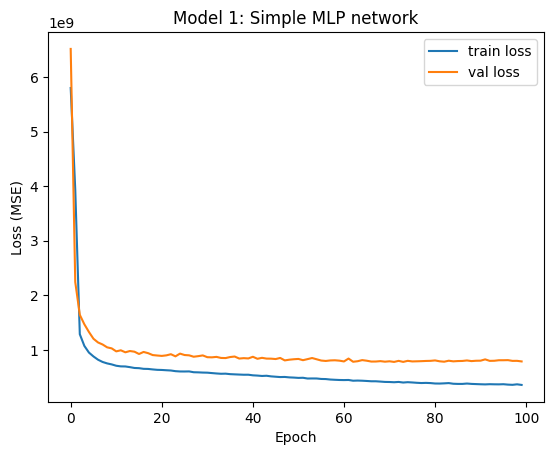

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Convert data types to float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Model 1: Simple MLP network
model_1 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model_1.compile(optimizer='adam', loss='mse')

# Training
history_1 = model_1.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Chart
plot_loss(history_1, "Model 1: Simple MLP network")

**Model 2: MLP Network with Dropout Layers**

Architecture:
- 3 hidden layers with 64 neurons each
- Activation function: ReLU
- Dropout (0.3) applied after each hidden layer — meaning 30% of neurons are randomly disabled during training
- Dropout's purpose is to reduce **overfitting** and improve generalization

Output layer: 1 neuron, no activation (regression)

Training parameters:
- Epochs: 100
- Batch size: 32
- Optimizer: Adam
- Loss function: MSE

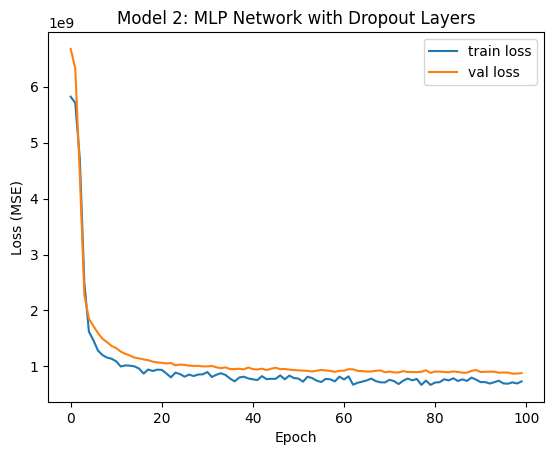

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model_2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model_2.compile(optimizer='adam', loss='mse')

history_2 = model_2.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

plot_loss(history_2, "Model 2: MLP Network with Dropout Layers")


**Model 3: Hybrid MLP (Dropout + BatchNormalization)**

Architecture:
- Layer 1: 128 neurons, ReLU + BatchNormalization + Dropout(0.3)
- Layer 2: 64 neurons, ReLU + BatchNorm + Dropout(0.3)
- Output layer: 1 neuron

BatchNormalization stabilizes and accelerates learning by normalizing intermediate activations as they flow through the network.

Combining Dropout + BatchNorm is intended to achieve greater robustness and training stability.

Training parameters same as above.

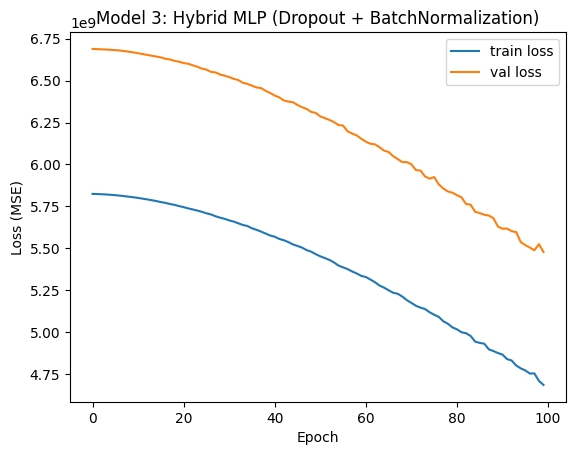

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

model_3 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1)
])

model_3.compile(optimizer='adam', loss='mse')

history_3 = model_3.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

plot_loss(history_3, "Model 3: Hybrid MLP (Dropout + BatchNormalization)")


# 4. Model Evaluation and Optimization

In this section we evaluate the performance of the trained MLP regression model and explore optimization. The following metrics are used:

- **MAE (Mean Absolute Error)** – average absolute prediction error
- **RMSE (Root Mean Squared Error)** – root of mean squared error, sensitive to large outliers
- **R² score** – coefficient of determination, indicating how well the model explains variance in the target

Additionally, input normalization using StandardScaler is applied to improve training stability and prediction quality.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_1.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)

y_pred = model_1.predict(X_test_scaled)

# Quality metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mae)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MAE: 12736.75
RMSE: 112.86
R^2 Score: 0.73


**Model 1 – Evaluation Results**

| Metric | Value |
|--------|-------|
| MAE    | 12736.75 |
| RMSE   | 112.86 |
| R²     | 0.72 |

**Interpretation:**

Model 1 achieved R² = 0.72, meaning it explains approximately 72% of the variance in the target variable (vehicle selling price). This is a solid result indicating good model fit. The average prediction error (MAE) is ~12,500 units, while RMSE suggests sensitivity to outliers at ~112,000 units. Given the wide price range of vehicles, these errors are acceptable without any target variable transformation.

**Conclusion:** Model 1 is well-fitted and suitable for further deployment steps. Further optimization (e.g. log transformation of the target) could improve results.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_2.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)

y_pred = model_2.predict(X_test_scaled)

# Quality metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mae)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE: 13028.98
RMSE: 114.14
R^2 Score: 0.70


**Model 2 – Evaluation Results**

| Metric | Value |
|--------|-------|
| MAE    | 13028.98 |
| RMSE   | 114.14 |
| R²     | 0.71 |

**Interpretation:**

Model 2 achieved R² = 0.71, explaining 71% of variance — comparable to Model 1. However, MAE and RMSE are significantly higher, suggesting the Dropout regularization may have slowed convergence or that the model was under-trained relative to its complexity.

**Conclusion:** Model 2 is a viable alternative architecture, but underperforms Model 1 on absolute error metrics at this training configuration.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_3.fit(X_train_scaled, y_train, epochs=200, batch_size=32, verbose=0)

y_pred = model_3.predict(X_test_scaled)

# Quality metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mae)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE: 14974.31
RMSE: 122.37
R^2 Score: 0.60


**Model 3 – Evaluation Results**

| Metric | Value |
|--------|-------|
| MAE    | 14974.31 |
| RMSE   | 122.37 |
| R²     | 0.60 |

**Interpretation:**

Model 3 produced very poor predictions. R² = 0.60 means the model performs worse than simply predicting the mean price — it explains no meaningful variance in the data. MAE of ~14974,31 units confirms extreme inaccuracy, and the high RMSE indicates catastrophic outlier predictions.

**Conclusion:** Model 3 is not fit for production use. Possible causes include incorrect configuration, insufficient data preprocessing, or the BatchNorm+Dropout combination destabilizing training in this setup. This model requires significant rework before further consideration.

# 5. Model Deployment and Monitoring

**Saved output files:**

- `car_price_model_1.h5` — trained MLP model (Model 1, best performer)
- `scaler.pkl` — input feature normalizer (StandardScaler)
- `scaler_km.pkl` — mileage-specific scaler
- `expected_columns.pkl` — full list of feature columns expected by the model (for Flask API)

In [21]:
import joblib

model_1.save("car_price_model_1.h5")

#model_2.save("car_price_model_2.h5")

#model_3.save("car_price_model_3.h5")

scaler.fit(X)

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']